# Validation 3, part 1: $M_{\mathrm{Het}}$ versus $M_{\mathrm{Hom}}$ at $N=500$

This first validation isolates **decision-level heterogeneity**. The history effects are not inferred here: $\beta_f$ and $\beta_s$ are fixed at their generating values in both fitted models,

$$\beta_f=0.8,\qquad \beta_s=-0.8.$$

Only two models are compared:

- $M_{\mathrm{Hom}}$: $\sigma_\eta=0$
- $M_{\mathrm{Het}}$: $\sigma_\eta$ is estimated

For each of the two ground truths, five independently simulated datasets are fitted. The plotted quantity is

$$\log_{10}\mathrm{BF}(M_{\mathrm{Het}}/M_{\mathrm{Hom}})=\frac{\log p(D\mid M_{\mathrm{Het}})-\log p(D\mid M_{\mathrm{Hom}})}{\log 10}.$$

Positive values support heterogeneity and negative values support homogeneity. Dots show the five replicate Bayes factors; the horizontal bar shows their mean.

Generate or resume the saved inference results from the project root with:

```bash
FORCE_RERUN=0 SHOW_PROGRESS=0 section_3/script/run_3_bf_500_fixed_beta.sh
```

The default `FORCE_RERUN=0` loads every compatible saved simulation and posterior. Use `FORCE_RERUN=1` only when all 20 fits should be regenerated.


In [36]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import NullLocator, MaxNLocator, MultipleLocator
from IPython.display import display
import arviz as az

try:
    import scienceplots

    plt.style.use(["science", "no-latex"])
except ModuleNotFoundError:
    plt.style.use("default")


NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]
        if (candidate / "section_3" / "script" / "run_3_bf_500_fixed_beta.sh").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the Barracuda project root.")

N_CELLS = 500
EXPECTED_REPLICATES = 5
SCENARIO_ORDER = ["No1", "No3"]
MODEL_ORDER = ["homogeneous_fixed_beta", "heterogeneous_fixed_beta"]

RESULT_ROOT = PROJECT_ROOT / "section_3" / "results" / "part_3_bf_500_fixed_beta"
FIGURE_ROOT = PROJECT_ROOT / "section_3" / "figures" / "part_3_bf_500_fixed_beta"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = RESULT_ROOT / f"logml_summary_n{N_CELLS}.csv"
CONFIG_PATH = RESULT_ROOT / f"run_config_n{N_CELLS}.json"
SCENARIOS_PATH = RESULT_ROOT / "scenarios.csv"

for required_path in (SUMMARY_PATH, CONFIG_PATH, SCENARIOS_PATH):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing {required_path}. Run section_3/script/run_3_bf_500_fixed_beta.sh first."
        )

bf_df = pd.read_csv(SUMMARY_PATH)
scenarios_df = pd.read_csv(SCENARIOS_PATH)
run_config = json.loads(CONFIG_PATH.read_text())

required_columns = {
    "scenario", "replicate", "simulation_seed", "n_cells",
    "gt_sigma_eta", "gt_beta_f", "gt_beta_s", "true_model",
    "best_model", "logml_homogeneous_fixed_beta",
    "logml_heterogeneous_fixed_beta",
    "log10_bf_heterogeneous_vs_homogeneous",
}
missing_columns = required_columns.difference(bf_df.columns)
if missing_columns:
    raise ValueError(f"{SUMMARY_PATH} is missing columns: {sorted(missing_columns)}")
if run_config.get("beta_mode") != "fixed_to_ground_truth":
    raise ValueError("The saved run did not fix beta_f and beta_s.")
if int(run_config["n_cells"]) != N_CELLS:
    raise ValueError("run_config n_cells does not match this notebook.")
if int(run_config["replicates"]) != EXPECTED_REPLICATES:
    raise ValueError("This notebook requires five completed replicates.")
if list(run_config["scenarios"]) != SCENARIO_ORDER:
    raise ValueError("Expected the No1 and No3 fixed-beta scenarios.")
if list(run_config["models"]) != MODEL_ORDER:
    raise ValueError("Expected exactly the homogeneous and heterogeneous fixed-beta models.")
if set(bf_df["n_cells"].astype(int)) != {N_CELLS}:
    raise ValueError("Summary contains an unexpected sample size.")
if not np.isfinite(
    bf_df[
        [
            "logml_homogeneous_fixed_beta",
            "logml_heterogeneous_fixed_beta",
            "log10_bf_heterogeneous_vs_homogeneous",
        ]
    ].to_numpy(dtype=float)
).all():
    raise ValueError("All marginal likelihoods and Bayes factors must be finite.")

key_columns = ["scenario", "replicate"]
if bf_df.duplicated(key_columns).any():
    raise ValueError("Duplicate scenario/replicate rows found.")
expected_keys = {
    (scenario, replicate)
    for scenario in SCENARIO_ORDER
    for replicate in range(1, EXPECTED_REPLICATES + 1)
}
actual_keys = set(
    bf_df.assign(scenario=bf_df["scenario"].astype(str))[key_columns]
    .itertuples(index=False, name=None)
)
if actual_keys != expected_keys:
    raise ValueError(
        f"Incomplete result grid: found {len(actual_keys)} of {len(expected_keys)} datasets."
    )
if not np.allclose(bf_df["gt_beta_f"], 0.8):
    raise ValueError("beta_f was not fixed at 0.8 in every dataset.")
if not np.allclose(bf_df["gt_beta_s"], -0.8):
    raise ValueError("beta_s was not fixed at -0.8 in every dataset.")

bf_df = bf_df.sort_values(["scenario", "replicate"]).reset_index(drop=True)
pd.set_option("display.max_columns", 100)
print(
    f"Validated {len(bf_df)} paired datasets: {len(SCENARIO_ORDER)} truths, "
    f"{EXPECTED_REPLICATES} replicates each, N={N_CELLS}."
)
bf_df.head()


OSError: 'science' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Replicate Bayes factors

The numerical summary is calculated in raw $\log_{10}$-BF space. A correct selection has a positive BF under heterogeneous truth and a negative BF under homogeneous truth.


In [3]:
BF_COLUMN = "log10_bf_heterogeneous_vs_homogeneous"
bf_df["correct_selection"] = np.where(
    bf_df["gt_sigma_eta"] > 0.0,
    bf_df[BF_COLUMN] > 0.0,
    bf_df[BF_COLUMN] < 0.0,
)

bf_summary = (
    bf_df.groupby("scenario", as_index=False)
    .agg(
        gt_sigma_eta=("gt_sigma_eta", "first"),
        beta_f=("gt_beta_f", "first"),
        beta_s=("gt_beta_s", "first"),
        mean_log10_bf=(BF_COLUMN, "mean"),
        sd_log10_bf=(BF_COLUMN, "std"),
        median_log10_bf=(BF_COLUMN, "median"),
        min_log10_bf=(BF_COLUMN, "min"),
        max_log10_bf=(BF_COLUMN, "max"),
        correct_fraction=("correct_selection", "mean"),
        n_replicates=("replicate", "nunique"),
    )
    .set_index("scenario")
    .loc[SCENARIO_ORDER]
    .reset_index()
)

REPLICATE_TABLE_PATH = RESULT_ROOT / f"pairwise_bf_fixed_beta_n{N_CELLS}.csv"
SUMMARY_TABLE_PATH = RESULT_ROOT / f"pairwise_bf_fixed_beta_summary_n{N_CELLS}.csv"
bf_df.to_csv(REPLICATE_TABLE_PATH, index=False)
bf_summary.to_csv(SUMMARY_TABLE_PATH, index=False)

display(
    bf_df[
        ["scenario", "replicate", "simulation_seed", BF_COLUMN, "correct_selection"]
    ].round(3)
)
display(bf_summary.round(3))


,scenario,replicate,simulation_seed,log10_bf_heterogeneous_vs_homogeneous,correct_selection
0,No1,1,10310,10.111,True
1,No1,2,20310,10.464,True
2,No1,3,30310,7.765,True
3,No1,4,40310,5.642,True
4,No1,5,50310,6.956,True
5,No3,1,10312,0.206,False
6,No3,2,20312,-0.933,True
7,No3,3,30312,-0.732,True
8,No3,4,40312,-0.713,True
9,No3,5,50312,-0.534,True


,scenario,gt_sigma_eta,beta_f,beta_s,mean_log10_bf,sd_log10_bf,median_log10_bf,min_log10_bf,max_log10_bf,correct_fraction,n_replicates
0,No1,0.75,0.8,-0.8,8.188,2.065,7.765,5.642,10.464,1.0,5
1,No3,0.00,0.8,-0.8,-0.541,0.441,-0.713,-0.933,0.206,0.8,5


In [4]:
HET_COLOR = "#566F94"
HOM_COLOR = "#7DB2AC"
BAND_COLORS = {
    "anecdotal": "#F7F7F7",
    "moderate": "#FFF3B0",
    "strong": "#FFD28A",
    "extreme": "#E76F51",
}
BF3 = float(np.log10(3.0))
RAW_BF_CLIP = 3.0


def to_even_bf_axis(values, *, clip_log10_bf: float = RAW_BF_CLIP) -> np.ndarray:
    raw = np.asarray(values, dtype=float)
    sign = np.sign(raw)
    magnitude = np.abs(raw)
    clip_log10_bf = max(float(clip_log10_bf), 2.0 + 1e-6)
    shown = np.zeros_like(magnitude, dtype=float)

    mask = magnitude <= BF3
    shown[mask] = magnitude[mask] / BF3
    mask = (magnitude > BF3) & (magnitude <= 1.0)
    shown[mask] = 1.0 + (magnitude[mask] - BF3) / (1.0 - BF3)
    mask = (magnitude > 1.0) & (magnitude <= 2.0)
    shown[mask] = 2.0 + (magnitude[mask] - 1.0)
    mask = magnitude > 2.0
    shown[mask] = 3.0 + np.minimum(
        (magnitude[mask] - 2.0) / (clip_log10_bf - 2.0),
        1.0,
    )
    return sign * shown


def add_horizontal_bf_bands(ax) -> None:
    bands = [
        (-4.0, -3.0, "extreme"),
        (-3.0, -2.0, "strong"),
        (-2.0, -1.0, "moderate"),
        (-1.0, 1.0, "anecdotal"),
        (1.0, 2.0, "moderate"),
        (2.0, 3.0, "strong"),
        (3.0, 4.0, "extreme"),
    ]
    for left, right, label in bands:
        ax.axvspan(left, right, color=BAND_COLORS[label], alpha=0.25, linewidth=0, zorder=0)
        if label != "anecdotal":
            ax.text(
                (left + right) / 2, 0.985, label.capitalize(),
                transform=ax.get_xaxis_transform(), ha="center", va="top",
                fontsize=9, color="0.25", alpha=0.70, zorder=1,
            )
    for level in (-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0):
        ax.axvline(
            level, color="black", linestyle="--" if level == 0 else ":",
            linewidth=1.45 if level == 0 else 0.8,
            alpha=0.85 if level == 0 else 0.42, zorder=1,
        )


def style_horizontal_bf_axis(ax) -> None:
    ax.set_xlim(-4.2, 4.2)
    ax.set_xticks(np.arange(-4, 5, 1))
    ax.set_xticklabels(
        [
            rf"$\leq-{RAW_BF_CLIP:g}$", "-2", "-1", r"$-\log_{10}3$",
            "0", r"$\log_{10}3$", "1", "2", rf"$\geq{RAW_BF_CLIP:g}$",
        ]
    )
    ax.tick_params(axis="both", which="major", labelsize=11)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("black")


In [13]:
HET_COLOR = "#566F94"
HOM_COLOR = "#7DB2AC"

BAND_COLORS = {
    "anecdotal": "#F7F7F7",
    "moderate": "#FFF3B0",
    "strong": "#FFD28A",
    "extreme": "#E76F51",
}

BF3 = float(np.log10(3.0))
RAW_BF_CLIP = 8


def to_real_bf_axis(
    values,
    *,
    clip_log10_bf: float = RAW_BF_CLIP,
) -> np.ndarray:
    """
    Preserve the real log10-BF scale while clipping values
    outside the displayed range.
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    return np.clip(
        values,
        -clip_log10_bf,
        clip_log10_bf,
    )


def add_horizontal_bf_bands(
    ax,
    *,
    limit: float = RAW_BF_CLIP,
) -> None:
    """
    Draw evidence regions at their actual log10-BF positions.
    """
    bands = [
        (-limit, -2.0, "extreme"),
        (-2.0, -1.0, "strong"),
        (-1.0, -BF3, "moderate"),
        (-BF3, BF3, "anecdotal"),
        (BF3, 1.0, "moderate"),
        (1.0, 2.0, "strong"),
        (2.0, limit, "extreme"),
    ]

    for left, right, label in bands:
        if right <= left:
            continue

        ax.axvspan(
            left,
            right,
            color=BAND_COLORS[label],
            alpha=0.25,
            linewidth=0,
            zorder=0,
        )

        if label != "anecdotal":
            ax.text(
                (left + right) / 2,
                0.985,
                label.capitalize(),
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=9,
                color="0.25",
                alpha=0.70,
                zorder=1,
            )

    threshold_positions = [
        -2.0,
        -1.0,
        -BF3,
        0.0,
        BF3,
        1.0,
        2.0,
    ]

    for position in threshold_positions:
        ax.axvline(
            position,
            color="black",
            linestyle=(
                "--"
                if position == 0
                else ":"
            ),
            linewidth=(
                1.45
                if position == 0
                else 0.8
            ),
            alpha=(
                0.85
                if position == 0
                else 0.42
            ),
            zorder=1,
        )


def style_horizontal_bf_axis(
    ax,
    *,
    limit: float = RAW_BF_CLIP,
) -> None:
    """
    Use real numerical log10-BF positions.
    """
    ax.set_xlim(
        -limit - 0.2,
        limit + 0.2,
    )

    tick_positions = [
        -limit,
        -2.0,
        -1.0,
        -BF3,
        0.0,
        BF3,
        1.0,
        2.0,
        limit,
    ]

    tick_labels = [
        rf"$\leq-{limit:g}$",
        "-2",
        "-1",
        r"$-\log_{10}3$",
        "0",
        r"$\log_{10}3$",
        "1",
        "2",
        rf"$\geq{limit:g}$",
    ]

    ax.set_xticks(
        tick_positions
    )

    ax.set_xticklabels(
        tick_labels
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=11,
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    ax.yaxis.set_minor_locator(
        NullLocator()
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("black")

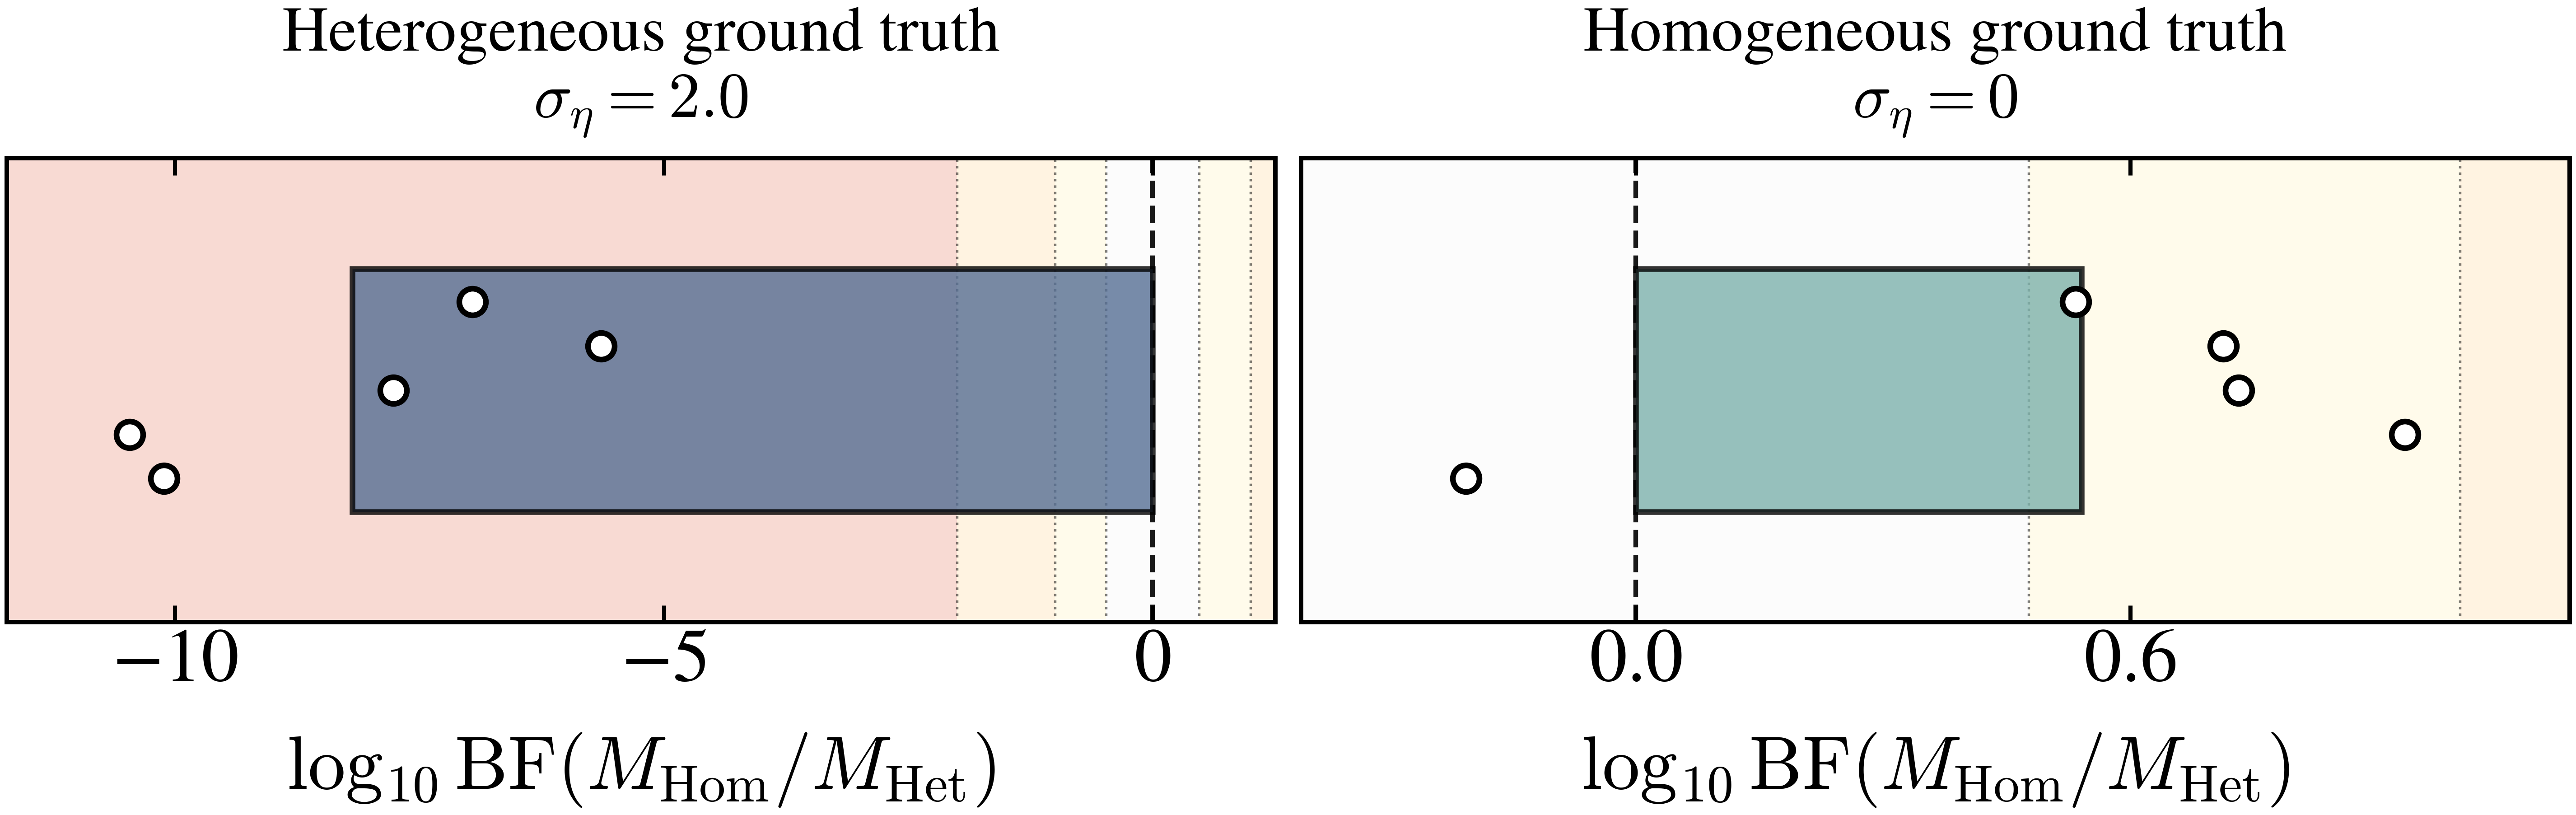

In [34]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, NullLocator


# ============================================================
# Real-scale log10 BF(M_Hom / M_Het), shown as 1 × 2 panels
# ============================================================

SOURCE_BF_COLUMN = (
    "log10_bf_heterogeneous_vs_homogeneous"
)

PLOT_BF_COLUMN = (
    "log10_bf_homogeneous_vs_heterogeneous"
)

bf_plot_df = bf_df.copy()

# Reverse the original Bayes-factor direction:
#
# log10 BF(M_Hom / M_Het)
# = -log10 BF(M_Het / M_Hom)
bf_plot_df[PLOT_BF_COLUMN] = (
    -bf_plot_df[SOURCE_BF_COLUMN]
)

BF3 = float(
    np.log10(3.0)
)

HET_COLOR = "#566f94"
HOM_COLOR = "#7db2ac"

BAND_COLORS = {
    "anecdotal": "#F7F7F7",
    "moderate": "#FFF3B0",
    "strong": "#FFD28A",
    "extreme": "#E76F51",
}

PANEL_TITLES = {
    "No1": (
        r"Heterogeneous ground truth"
        "\n"
        r"$\sigma_\eta=2.0$"
    ),
    "No3": (
        r"Homogeneous ground truth"
        "\n"
        r"$\sigma_\eta=0$"
    ),
}

# Optionally provide manual limits.
# Leave as None to calculate each panel's limits independently.
CUSTOM_XLIMS = {
    "No1": None,
    "No3": None,

    # Examples:
    # "No1": (-20, 2),
    # "No3": (-2, 20),
}


def add_real_bf_background(
    ax,
    *,
    x_min: float,
    x_max: float,
) -> None:
    """
    Draw evidence-strength regions at their actual
    log10 Bayes-factor coordinates.
    """
    regions = [
        (
            x_min,
            min(-2.0, x_max),
            "extreme",
        ),
        (
            max(-2.0, x_min),
            min(-1.0, x_max),
            "strong",
        ),
        (
            max(-1.0, x_min),
            min(-BF3, x_max),
            "moderate",
        ),
        (
            max(-BF3, x_min),
            min(BF3, x_max),
            "anecdotal",
        ),
        (
            max(BF3, x_min),
            min(1.0, x_max),
            "moderate",
        ),
        (
            max(1.0, x_min),
            min(2.0, x_max),
            "strong",
        ),
        (
            max(2.0, x_min),
            x_max,
            "extreme",
        ),
    ]

    for left, right, strength in regions:
        if right <= left:
            continue

        ax.axvspan(
            left,
            right,
            color=BAND_COLORS[strength],
            alpha=0.25,
            linewidth=0,
            zorder=0,
        )

    threshold_positions = [
        -2.0,
        -1.0,
        -BF3,
        0.0,
        BF3,
        1.0,
        2.0,
    ]

    for position in threshold_positions:
        if not (
            x_min <= position <= x_max
        ):
            continue

        ax.axvline(
            position,
            color="black",
            linestyle=(
                "--"
                if position == 0
                else ":"
            ),
            linewidth=(
                2.5
                if position == 0
                else 1.3
            ),
            alpha=(
                0.90
                if position == 0
                else 0.50
            ),
            zorder=1,
        )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 6),
    dpi=300,

    # Different x-limits for the two panels.
    sharex=False,
    sharey=True,
    constrained_layout=True,
)

for ax, scenario in zip(
    axes,
    SCENARIO_ORDER,
):
    scenario_data = (
        bf_plot_df[
            bf_plot_df["scenario"].astype(str)
            == scenario
        ]
        .sort_values("replicate")
    )

    values = scenario_data[
        PLOT_BF_COLUMN
    ].to_numpy(dtype=float)

    values = values[
        np.isfinite(values)
    ]

    if values.size == 0:
        ax.set_visible(False)
        continue

    mean_value = float(
        np.mean(values)
    )

    # --------------------------------------------------------
    # Independent x-limits for this panel
    # --------------------------------------------------------
    manual_xlim = CUSTOM_XLIMS.get(
        scenario
    )

    if manual_xlim is None:
        data_min = min(
            0.0,
            float(np.min(values)),
            mean_value,
        )

        data_max = max(
            0.0,
            float(np.max(values)),
            mean_value,
        )

        data_range = (
            data_max - data_min
        )

        if data_range <= 0:
            data_range = 1.0

        padding = max(
            0.20,
            0.12 * data_range,
        )

        x_min = (
            data_min - padding
        )

        x_max = (
            data_max + padding
        )
    else:
        x_min = float(
            manual_xlim[0]
        )

        x_max = float(
            manual_xlim[1]
        )

        if x_max <= x_min:
            raise ValueError(
                f"Invalid x-limits for {scenario}: "
                f"{manual_xlim}"
            )

    ax.set_xlim(
        x_min,
        x_max,
    )

    add_real_bf_background(
        ax,
        x_min=x_min,
        x_max=x_max,
    )

    # Positive BF supports M_Hom.
    # Negative BF supports M_Het.
    mean_color = (
        HOM_COLOR
        if mean_value >= 0
        else HET_COLOR
    )

    # Mean bar.
    ax.barh(
        [0],
        [mean_value],
        height=0.44,
        color=mean_color,
        alpha=0.8,
        edgecolor="black",
        linewidth=3,
        zorder=2,
    )

    # Individual replicate positions.
    replicate_offsets = np.linspace(
        -0.16,
        0.16,
        values.size,
    )

    ax.scatter(
        values,
        replicate_offsets,
        s=200,
        facecolor="white",
        edgecolor="black",
        linewidth=3.0,
        zorder=4,
    )

    # Mean annotation.
    if mean_value >= 0:
        annotation_offset = 12
        horizontal_alignment = "left"
    else:
        annotation_offset = -12
        horizontal_alignment = "right"

    ax.set_title(
        PANEL_TITLES.get(
            scenario,
            scenario,
        ),
        fontsize=34,
        pad=22,
    )

    ax.set_xlabel(
        (
            r"$\log_{10}\mathrm{BF}"
            r"(M_{\mathrm{Hom}}/M_{\mathrm{Het}})$"
        ),
        fontsize=40,
        labelpad=18,
    )

    ax.set_ylim(
        -0.42,
        0.42,
    )

    ax.set_yticks([])

    ax.tick_params(
        axis="x",
        which="major",
        labelsize=40,
        width=2.2,
        length=9,
    )

    # Correct argument: nbins, not n_bins.
    ax.xaxis.set_major_locator(
        MaxNLocator(
            nbins=3,
        )
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2.4)



legend_handles = [
    Patch(
        facecolor="0.55",
        edgecolor="black",
        alpha=0.65,
        label="Mean log-BF",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="0.25",
        markeredgewidth=2.5,
        markersize=12,
        label="Individual replicate",
    ),
]



FIGURE_STEM = (
    FIGURE_ROOT
    / (
        "bf_homogeneous_vs_heterogeneous_"
        f"separate_panels_n{N_CELLS}"
    )
)

FIGURE_PATHS_SEPARATE = {
    "svg": FIGURE_STEM.with_suffix(
        ".svg"
    ),
    "png": FIGURE_STEM.with_suffix(
        ".png"
    ),
}

fig.savefig(
    FIGURE_PATHS_SEPARATE["svg"],
    format="svg",
    bbox_inches="tight",
    pad_inches=0.25,
    transparent=True,
)

fig.savefig(
    FIGURE_PATHS_SEPARATE["png"],
    format="png",
    bbox_inches="tight",
    pad_inches=0.25,
    dpi=300,
    facecolor="white",
)

plt.show()

# FIGURE_PATHS_SEPARATE

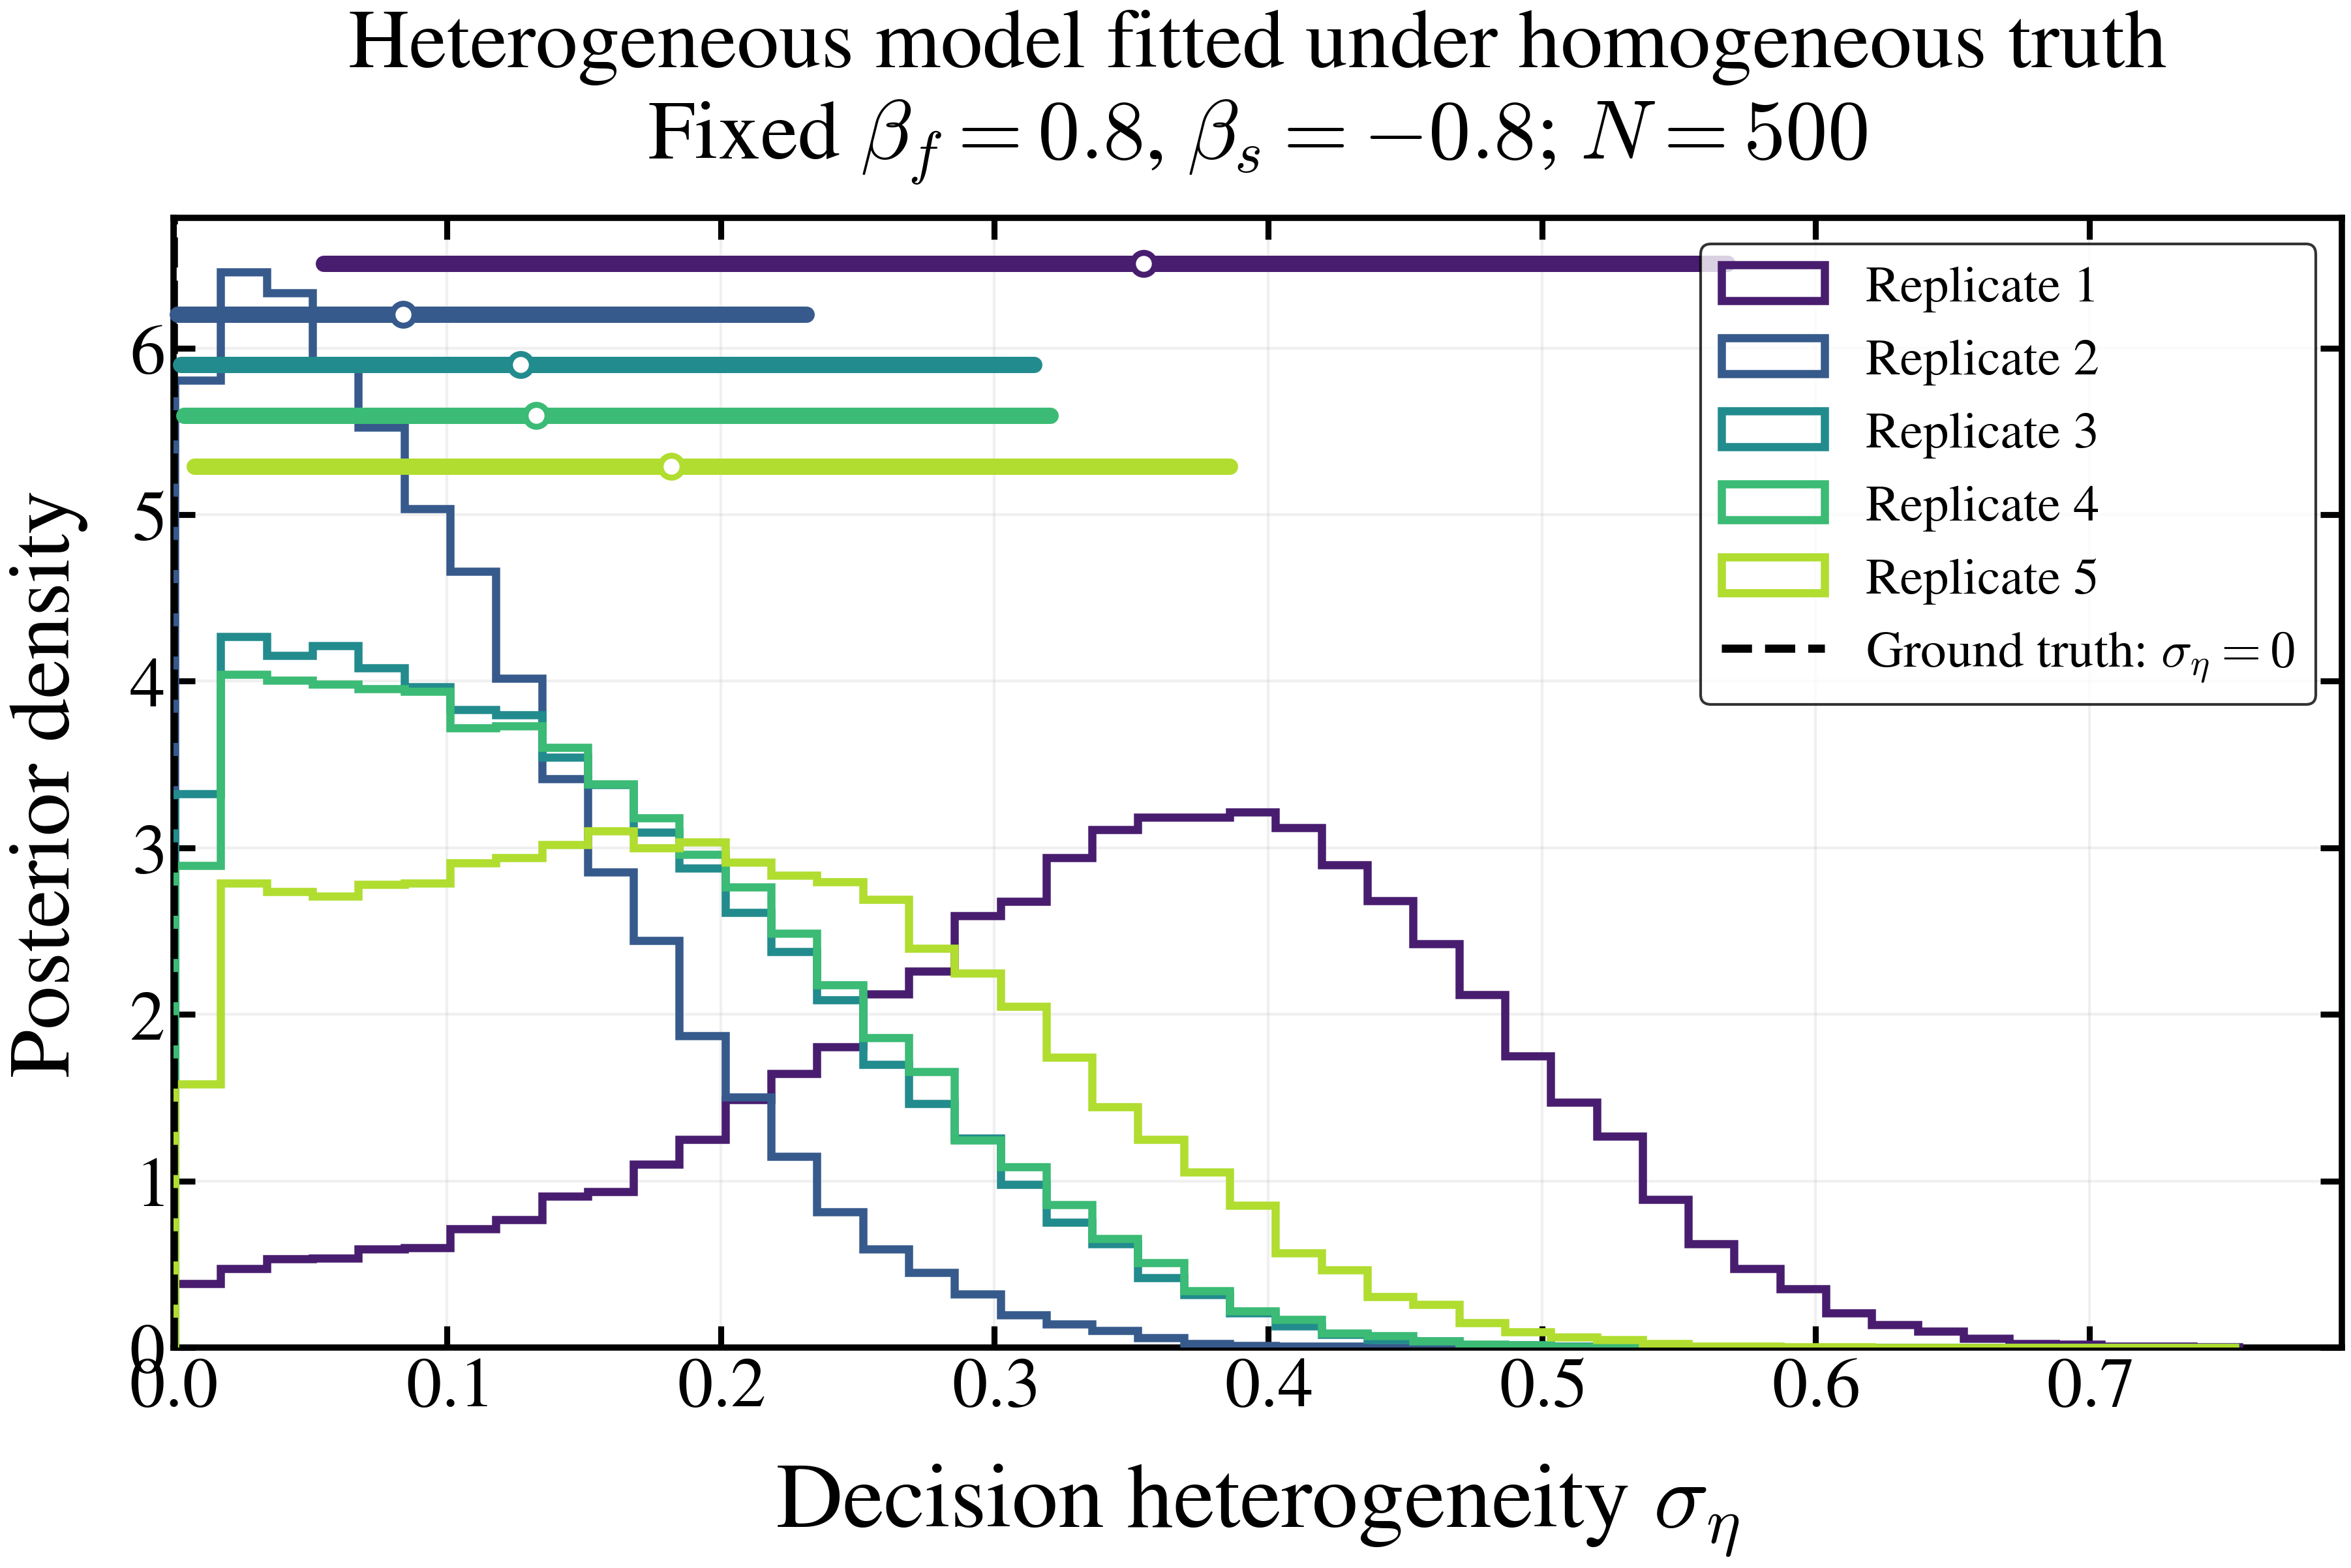

,replicate,n_particles,posterior_mean,posterior_median,posterior_sd,hdi_2.5%,hdi_97.5%,P(sigma_eta < 0.1)
0,1,60000,0.3424,0.3545,0.1296,0.0549,0.5678,0.0514
1,2,60000,0.0973,0.0839,0.0701,0.0016,0.2314,0.5815
2,3,60000,0.1404,0.1267,0.0935,0.0027,0.3144,0.3980
3,4,60000,0.1454,0.1327,0.0946,0.0039,0.3204,0.3784
4,5,60000,0.1896,0.1818,0.1117,0.0077,0.3859,0.2546


PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_3/figures/part_3_bf_500_fixed_beta/sigma_eta_marginal_posterior_under_homogeneous_truth.svg')

In [37]:
# ============================================================
# Marginal posterior of sigma_eta under homogeneous truth
#
# Ground truth: No3, sigma_eta = 0
# Fitted model: heterogeneous_fixed_beta
# ============================================================

HOMOGENEOUS_TRUTH_SCENARIO = "No3"
SIGMA_MODEL = "heterogeneous_fixed_beta"
TRUE_SIGMA_ETA = 0.0

REPLICATES_TO_PLOT = range(
    1,
    EXPECTED_REPLICATES + 1,
)

N_BINS = 45
HDI_PROBABILITY = 0.95

# This threshold is optional and can be changed.
NEAR_ZERO_THRESHOLD = 0.10

sigma_samples_by_replicate = {}
summary_rows = []

for replicate in REPLICATES_TO_PLOT:
    posterior_path = (
        RESULT_ROOT
        / HOMOGENEOUS_TRUTH_SCENARIO
        / f"rep_{replicate:03d}"
        / f"n_{N_CELLS}"
        / SIGMA_MODEL
        / "posterior.nc"
    )

    if not posterior_path.exists():
        raise FileNotFoundError(
            f"Missing posterior: {posterior_path}"
        )

    idata = az.from_netcdf(
        str(posterior_path)
    )

    if "sigma_eta" not in idata.posterior:
        raise KeyError(
            f"{posterior_path} does not contain sigma_eta."
        )

    # Stack every chain and every SMC particle.
    sigma_eta = np.asarray(
        idata.posterior["sigma_eta"]
        .stack(
            sample=("chain", "draw")
        )
        .values,
        dtype=float,
    ).ravel()

    sigma_eta = sigma_eta[
        np.isfinite(sigma_eta)
    ]

    if sigma_eta.size == 0:
        raise ValueError(
            f"No finite sigma_eta particles in {posterior_path}."
        )

    sigma_samples_by_replicate[
        replicate
    ] = sigma_eta

    hdi_low, hdi_high = az.hdi(
        sigma_eta,
        hdi_prob=HDI_PROBABILITY,
    )

    summary_rows.append(
        {
            "replicate": replicate,
            "n_particles": int(
                sigma_eta.size
            ),
            "posterior_mean": float(
                np.mean(sigma_eta)
            ),
            "posterior_median": float(
                np.median(sigma_eta)
            ),
            "posterior_sd": float(
                np.std(
                    sigma_eta,
                    ddof=1,
                )
            ),
            "hdi_2.5%": float(
                hdi_low
            ),
            "hdi_97.5%": float(
                hdi_high
            ),
            (
                f"P(sigma_eta < "
                f"{NEAR_ZERO_THRESHOLD:g})"
            ): float(
                np.mean(
                    sigma_eta
                    < NEAR_ZERO_THRESHOLD
                )
            ),
        }
    )

# Use common histogram bins so the replicate posteriors
# can be compared directly.
all_sigma_samples = np.concatenate(
    list(
        sigma_samples_by_replicate.values()
    )
)

bin_edges = np.histogram_bin_edges(
    all_sigma_samples,
    bins=N_BINS,
)

replicate_colors = plt.get_cmap(
    "viridis"
)(
    np.linspace(
        0.08,
        0.88,
        len(sigma_samples_by_replicate),
    )
)

fig, ax = plt.subplots(
    figsize=(12, 8),
    dpi=300,
    constrained_layout=True,
)

# Separate y positions for the replicate-specific HDI bars.
hdi_positions = np.linspace(
    0.96,
    0.78,
    len(sigma_samples_by_replicate),
)

for (
    replicate,
    color,
    hdi_y,
) in zip(
    sigma_samples_by_replicate,
    replicate_colors,
    hdi_positions,
):
    sigma_eta = (
        sigma_samples_by_replicate[
            replicate
        ]
    )

    # Marginal posterior histogram using all particles.
    ax.hist(
        sigma_eta,
        bins=bin_edges,
        density=True,
        histtype="step",
        color=color,
        linewidth=3.0,
        label=f"Replicate {replicate}",
        zorder=3,
    )

    hdi_low, hdi_high = az.hdi(
        sigma_eta,
        hdi_prob=HDI_PROBABILITY,
    )

    median = float(
        np.median(sigma_eta)
    )

    # Horizontal 95% HDI bar.
    ax.plot(
        [
            float(hdi_low),
            float(hdi_high),
        ],
        [
            hdi_y,
            hdi_y,
        ],
        transform=ax.get_xaxis_transform(),
        color=color,
        linewidth=6,
        solid_capstyle="round",
        zorder=5,
        clip_on=False,
    )

    # Posterior median on the HDI bar.
    ax.scatter(
        [median],
        [hdi_y],
        transform=ax.get_xaxis_transform(),
        s=65,
        facecolor="white",
        edgecolor=color,
        linewidth=2.2,
        zorder=6,
        clip_on=False,
    )

# Ground-truth value.
ax.axvline(
    TRUE_SIGMA_ETA,
    color="black",
    linewidth=3.0,
    linestyle="--",
    label=r"Ground truth: $\sigma_\eta=0$",
    zorder=4,
)

ax.set_xlim(
    left=0,
)

ax.set_xlabel(
    r"Decision heterogeneity $\sigma_\eta$",
    fontsize=34,
    labelpad=15,
)

ax.set_ylabel(
    "Posterior density",
    fontsize=32,
    labelpad=15,
)

ax.set_title(
    (
        "Heterogeneous model fitted under homogeneous truth\n"
        rf"Fixed $\beta_f=0.8$, "
        rf"$\beta_s=-0.8$; "
        rf"$N={N_CELLS}$"
    ),
    fontsize=31,
    pad=22,
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=26,
    width=2.2,
    length=8,
)

ax.xaxis.set_minor_locator(
    NullLocator()
)

ax.yaxis.set_minor_locator(
    NullLocator()
)

ax.grid(
    alpha=0.18,
    linewidth=1.0,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2.3)

ax.legend(
    loc="upper right",
    frameon=True,
    edgecolor="black",
    fontsize=19,
)

out_path = (
    FIGURE_ROOT
    / (
        "sigma_eta_marginal_posterior_"
        "under_homogeneous_truth.svg"
    )
)

fig.savefig(
    out_path,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.2,
    transparent=True,
)

png_path = out_path.with_suffix(
    ".png"
)

fig.savefig(
    png_path,
    format="png",
    bbox_inches="tight",
    pad_inches=0.2,
    dpi=300,
    facecolor="white",
)

plt.show()

sigma_eta_summary = pd.DataFrame(
    summary_rows
)

display(
    sigma_eta_summary.round(4)
)

out_path